# Carolina - Daily screen time

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.stats import linregress

In [ ]:
# load data
df = pd.read_csv()

# check head
df.head(10)

,user_id,age,gender,sleep_duration,stress_level,diet_type,daily_screen_time,exercise_frequency,caffeine_intake,reaction_time,memory_test_score,cognitive_score,ai_predicted_score,age_group
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77,45-59
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68,30-44
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54,18-29
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59,30-44
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78,45-59
5,U6,36,Female,7.4,10,Vegan,6.6,Low,381,453.43,70,31.71,32.77,30-44
6,U7,48,Male,6.7,2,Vegan,1.4,Low,39,407.13,51,59.17,55.92,45-59
7,U8,35,Female,6.0,1,Vegan,6.8,Medium,2,298.46,60,85.02,81.45,30-44
8,U9,29,Male,5.1,6,Non-Vegetarian,10.2,Low,244,380.08,82,50.67,54.17,18-29
9,U10,57,Female,7.9,9,Non-Vegetarian,9.1,High,355,417.96,54,44.39,43.88,45-59


In [4]:
# shape: 80.000 rows, 14 columns
df.shape

(80000, 14)

# Variable check

In [5]:
# a. Range
print('Min: ', df['daily_screen_time'].min(), ' hours')
print('Max: ', df['daily_screen_time'].max(), ' hours')

Min:  1.0  hours
Max:  12.0  hours


In [6]:
# b. Missing values
print('Missing values: ', df['daily_screen_time'].isna().sum())

Missing values:  0


In [25]:
# c. Outliers, strange values
# Best way is to first visualize the distribution

# Distribution

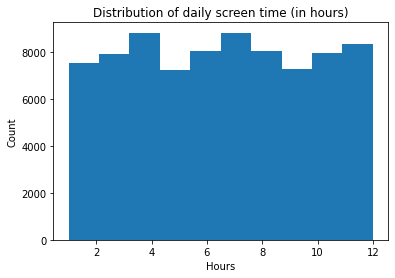

In [7]:
# Let's visualize

# Daily screen time (my variable)
plt.figure()
plt.hist(df['daily_screen_time'])
plt.title('Distribution of daily screen time (in hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

Looks like a rather uniform distribution, which is actually quite weird. I would expect a more normal distribution. Given the range of ages included in this dataset I would look within each age group.

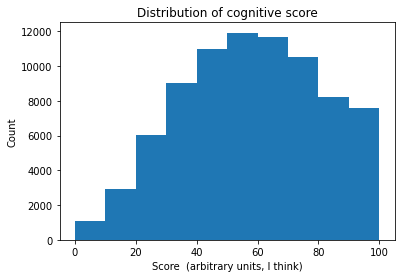

In [8]:
# Target variable: cognitive score
plt.figure()
plt.hist(df['cognitive_score'])
plt.title('Distribution of cognitive score')
plt.xlabel('Score  (arbitrary units, I think)')
plt.ylabel('Count')
plt.show()

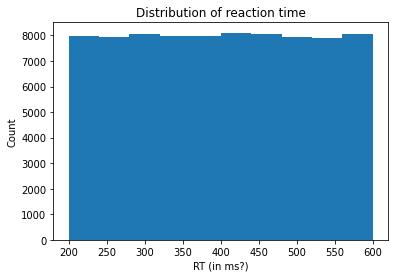

In [9]:
# Target variable: reaction time
plt.figure()
plt.hist(df['reaction_time'])
plt.title('Distribution of reaction time')
plt.xlabel('RT (in ms?)')
plt.ylabel('Count')
plt.show()

This is a REALLY strange distribution of reaction time.

# Summary statistics

In [10]:
# .describe() tells us some stats
print(df['daily_screen_time'].describe())

# Median
print('Median: ', df['daily_screen_time'].median())


count    80000.000000
mean         6.504646
std          3.167072
min          1.000000
25%          3.800000
50%          6.500000
75%          9.200000
max         12.000000
Name: daily_screen_time, dtype: float64
Median:  6.5


In [11]:
# .describe() tells us some stats
print(df['cognitive_score'].describe())

# Median
print('Median: ', df['cognitive_score'].median())

count    80000.000000
mean        58.172395
std         23.058522
min          0.000000
25%         40.910000
50%         58.360000
75%         75.830000
max        100.000000
Name: cognitive_score, dtype: float64
Median:  58.36


In [13]:
# .describe() tells us some stats
print(df['reaction_time'].describe())

# Median
print('Median: ', df['reaction_time'].median())

count    80000.000000
mean       399.973579
std        115.369329
min        200.000000
25%        300.150000
50%        400.360000
75%        499.250000
max        599.990000
Name: reaction_time, dtype: float64
Median:  400.36


# Age group breakdown

In [14]:
# Compare relationships acrosss age bins
# Age bins: 18-29, 30-44, 45-59, 60+

df.groupby('age_group')['daily_screen_time'].mean()

age_group
18-29    6.520210
30-44    6.504273
45-59    6.492627
Name: daily_screen_time, dtype: float64

# Gender breakdown

In [16]:
# Compare relationships across gender groups
gender_groups = df['gender'].unique()
df.groupby('gender')['daily_screen_time'].mean()



gender
Female    6.484723
Male      6.530124
Other     6.440134
Name: daily_screen_time, dtype: float64

# Correlations
First across the whole sample, then broken down into age groups and genders.

## Daily screen time and cognitive score

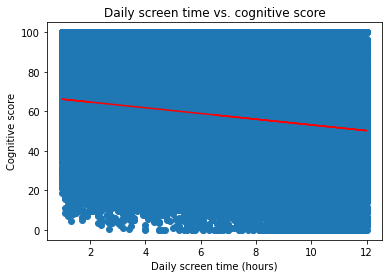

In [17]:
# My variable vs. cognitive score
slope, intercept, r_value, p_value, std_err = linregress(df['daily_screen_time'], df['cognitive_score'])
regression_line = slope * df['daily_screen_time'] + intercept
plt.scatter(df['daily_screen_time'], df['cognitive_score'])
plt.plot(df['daily_screen_time'], regression_line, color='red')
plt.title('Daily screen time vs. cognitive score')
plt.xlabel('Daily screen time (hours)')
plt.ylabel('Cognitive score')
plt.show()

In [18]:
# let's run some stats
r, pval = spearmanr(df['daily_screen_time'], df['cognitive_score'], alternative='less')
print(f'r = {r}, pval = {pval}')

r = -0.19011587605468724, pval = 0.0


Interpretation: Daily screen time is negatively associated with cognitive score, i.e. people who spend more time in front of a screen tend to show lower scores. P-val is suspiciously low though.

## Daily screen time and reaction time

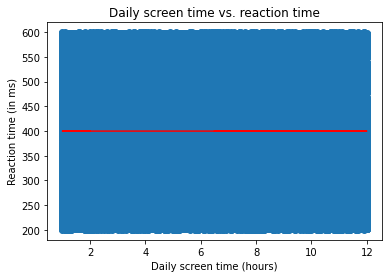

In [19]:
# My variable vs. reaction time
slope, intercept, r_value, p_value, std_err = linregress(df['daily_screen_time'], df['reaction_time'])
regression_line = slope * df['daily_screen_time'] + intercept
plt.scatter(df['daily_screen_time'], df['reaction_time'])
plt.plot(df['daily_screen_time'], regression_line, color='red')
plt.title('Daily screen time vs. reaction time')
plt.xlabel('Daily screen time (hours)')
plt.ylabel('Reaction time (in ms)')
plt.show()

I'm not surprised about the slope, but the fact that all age groups have the same RT is highly unlikely in real life.

In [20]:
# let's run some stats
r, pval = spearmanr(df['daily_screen_time'], df['reaction_time'], alternative='less')
print(f'r = {r}, pval = {pval}')

r = 9.422396981406077e-05, pval = 0.5106306119760274


Interpretation: no significant correlation between daily screen time and reaction time. That said I don't know what kind of task this was.

## Breakdown by age group

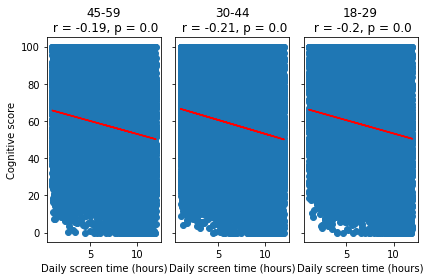

In [21]:
age_groups = df['age_group'].unique()

# create plot for subplots
fix, axes = plt.subplots(1,3, sharey=True)

# iterate over age groups to fill subplots
for ax, group in zip(axes, age_groups):
    subset = df[df['age_group'] == group]
    # plot
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['daily_screen_time'],
        subset['cognitive_score']
    )
    regression_line = slope * subset['daily_screen_time'] + intercept

    ax.scatter(subset['daily_screen_time'], subset['cognitive_score'])
    ax.plot(subset['daily_screen_time'], regression_line, color='red')

    ax.set_title(f'{group}\n r = {round(r_value,2)}, p = {round(p_value,2)}')
    ax.set_xlabel('Daily screen time (hours)')
axes[0].set_ylabel('Cognitive score')

plt.tight_layout()
plt.show()

There doesn't seem to be a difference in slope between age groups. However, there also doesn't seem to be a difference in score range, which is really strange. I bet that if I did an ANOVA it wouldn't show any differences between groups.

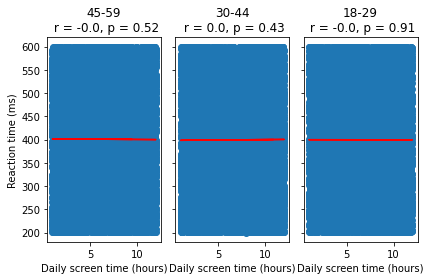

In [22]:
# let's look at reaction times now

# create plot for subplots
fix, axes = plt.subplots(1,3, sharey=True)

# iterate over age groups to fill subplots
for ax, group in zip(axes, age_groups):
    subset = df[df['age_group'] == group]
    # plot
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['daily_screen_time'],
        subset['reaction_time']
    )
    regression_line = slope * subset['daily_screen_time'] + intercept

    ax.scatter(subset['daily_screen_time'], subset['reaction_time'])
    ax.plot(subset['daily_screen_time'], regression_line, color='red')

    ax.set_title(f'{group}\n r = {round(r_value,2)}, p = {round(p_value,2)}')
    ax.set_xlabel('Daily screen time (hours)')
axes[0].set_ylabel('Reaction time (ms)')

plt.tight_layout()
plt.show()

## Breakdown by gender

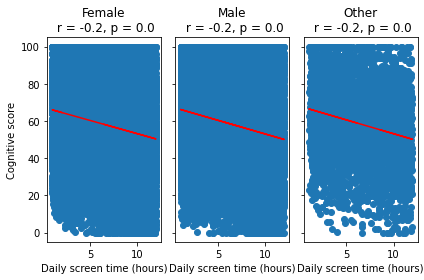

In [23]:
# create plot for subplots
fix, axes = plt.subplots(1,3, sharey=True)

# iterate over age groups to fill subplots
for ax, group in zip(axes, gender_groups):
    subset = df[df['gender'] == group]
    # plot
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['daily_screen_time'],
        subset['cognitive_score']
    )
    regression_line = slope * subset['daily_screen_time'] + intercept

    ax.scatter(subset['daily_screen_time'], subset['cognitive_score'])
    ax.plot(subset['daily_screen_time'], regression_line, color='red')

    ax.set_title(f'{group}\n r = {round(r_value,2)}, p = {round(p_value,2)}')
    ax.set_xlabel('Daily screen time (hours)')
axes[0].set_ylabel('Cognitive score')

plt.tight_layout()
plt.show()

I wouldn't expect much difference here, so this looks reasonable.

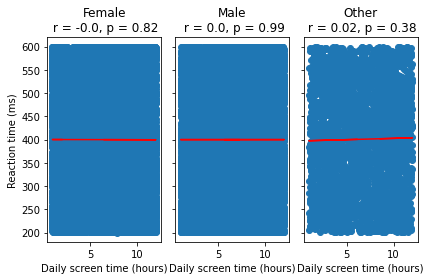

In [24]:
# create plot for subplots
fix, axes = plt.subplots(1,3, sharey=True)

# iterate over age groups to fill subplots
for ax, group in zip(axes, gender_groups):
    subset = df[df['gender'] == group]
    # plot
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['daily_screen_time'],
        subset['reaction_time']
    )
    regression_line = slope * subset['daily_screen_time'] + intercept

    ax.scatter(subset['daily_screen_time'], subset['reaction_time'])
    ax.plot(subset['daily_screen_time'], regression_line, color='red')

    ax.set_title(f'{group}\n r = {round(r_value,2)}, p = {round(p_value,2)}')
    ax.set_xlabel('Daily screen time (hours)')
axes[0].set_ylabel('Reaction time (ms)')

plt.tight_layout()
plt.show()

# Interpretation
* Daily screen time doesn't seem to be associated with reaction times at all, but is negatively associated with cognitive score. The results remain even when breaking down into different age groups and genders.
* I wouldn't go further in the interpretations because I don't know where the data comes from: how was it collected? How were participants sampled? Is this a real dataset or a synthetic one?

# Discussion question

The general question I have is where does this data come from? Why do the distributions look like this? A lot of it looks suspicious (e.g. uniform distributions, correlations with a p-value of pretty much 0, no apparent differences between age groups in variables one would expect).